In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
img = cv2.imread("003.png", cv2.IMREAD_GRAYSCALE)

In [4]:
blur = cv2.GaussianBlur(img, (5,5), 0)

In [5]:
_, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

In [6]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))

In [7]:
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)   # remove noise
closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel) # fill small holes

In [8]:
contours, _ = cv2.findContours(closing, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
result = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

In [9]:

for c in contours:
    if cv2.contourArea(c) > 200:  # filter tiny noise
        x,y,w,h = cv2.boundingRect(c)
        cv2.rectangle(result, (x,y), (x+w,y+h), (0,0,255), 2)

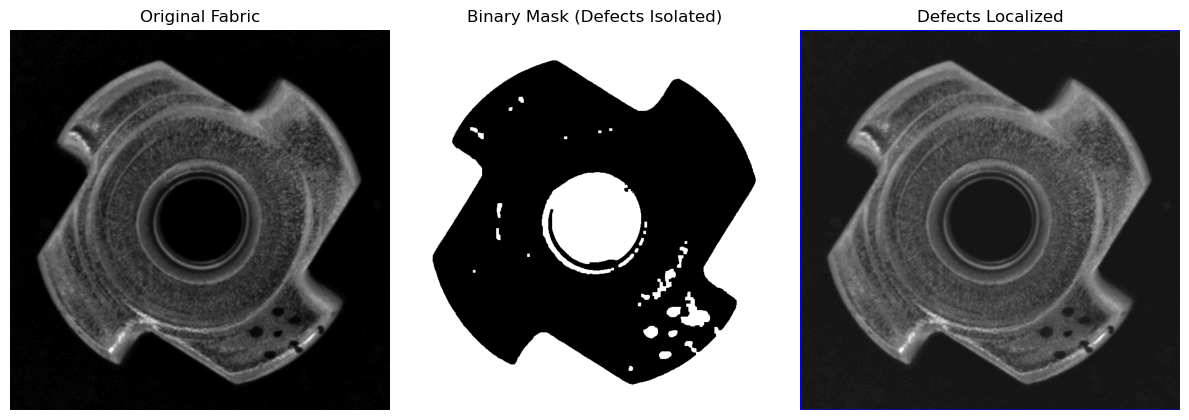

In [10]:
plt.figure(figsize=(12,6))

plt.subplot(1,3,1), plt.imshow(img, cmap='gray'), plt.title("Original Fabric"), plt.axis("off")
plt.subplot(1,3,2), plt.imshow(closing, cmap='gray'), plt.title("Binary Mask (Defects Isolated)"), plt.axis("off")
plt.subplot(1,3,3), plt.imshow(result), plt.title("Defects Localized"), plt.axis("off")

plt.tight_layout()
plt.show()
